In [1]:
from pathlib import Path
from tqdm import tqdm
import torch
from datasets import load_dataset, concatenate_datasets, Dataset
from tokenizers import Tokenizer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
class FeedForward(torch.nn.Module):

    def __init__(self, emb_size: int):
        super().__init__()
        self.lm1 = torch.nn.Linear(emb_size, 4 * emb_size)
        self.lm2 = torch.nn.Linear(4 * emb_size, emb_size)
        self.dp = torch.nn.Dropout(0.4)

    def forward(self, x: torch.Tensor):
        out = torch.nn.functional.gelu(self.lm1(x))
        out = self.dp(self.lm2(out))
        return out


class SelfAttention(torch.nn.Module):
    def __init__(self, emb_size: int, head_size: int):
        self.head_size = head_size
        super().__init__()
        self.key = torch.nn.Linear(emb_size, head_size, bias=False)
        self.query = torch.nn.Linear(emb_size, head_size, bias=False)
        self.value = torch.nn.Linear(emb_size, head_size, bias=False)

    def forward(self, x: torch.Tensor, mask: torch.Tensor | None):
        key = self.key(x)
        query = self.query(x)
        value = self.value(x)
        scores = query @ key.transpose(-2, -1) / self.head_size**0.5
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        w_att = torch.softmax(scores, dim=-1)
        return w_att @ value


class SelfMultiHeadAttention(torch.nn.Module):
    def __init__(self, emb_size: int, head_size: int):
        assert emb_size % head_size == 0
        super().__init__()
        # 计算单头注意力的个数
        n_head = emb_size // head_size
        self.heads = torch.nn.ModuleList(SelfAttention(emb_size, head_size) for _ in range(n_head))
        self.proj = torch.nn.Linear(emb_size, emb_size)
        self.dp = torch.nn.Dropout(0.4)

    def forward(self, x: torch.Tensor, mask: torch.Tensor):
        mha = torch.cat([h(x, mask) for h in self.heads], dim=-1)
        mha = self.dp(self.proj(mha))
        return mha


class CrossAttention(torch.nn.Module):
    def __init__(self, emb_size: int, head_size: int):
        self.head_size = head_size
        super().__init__()
        self.key = torch.nn.Linear(emb_size, head_size, bias=False)
        self.query = torch.nn.Linear(emb_size, head_size, bias=False)
        self.value = torch.nn.Linear(emb_size, head_size, bias=False)

    def forward(self, x: torch.Tensor, y: torch.Tensor):
        key = self.key(y)
        query = self.query(x)
        value = self.value(y)
        scores = query @ key.transpose(-2, -1) / self.head_size**0.5
        w_att = torch.softmax(scores, dim=-1)
        return w_att @ value


class CrossMultiHeadAttention(torch.nn.Module):
    def __init__(self, emb_size: int, head_size: int):
        assert emb_size % head_size == 0
        super().__init__()
        # 计算单头注意力的个数
        n_head = emb_size // head_size
        self.heads = torch.nn.ModuleList(CrossAttention(emb_size, head_size) for _ in range(n_head))
        self.proj = torch.nn.Linear(emb_size, emb_size)
        self.dp = torch.nn.Dropout(0.4)

    def forward(self, x: torch.Tensor, y: torch.Tensor):
        cross_mha = torch.cat([h(x, y) for h in self.heads], dim=-1)
        mha = self.dp(self.proj(cross_mha))
        return mha


class EncoderBlock(torch.nn.Module):
    def __init__(self, emb_size: int, head_size: int):
        super().__init__()
        self.mha_ln = torch.nn.LayerNorm(emb_size)
        self.mha = SelfMultiHeadAttention(emb_size, head_size)
        self.ff_ln = torch.nn.LayerNorm(emb_size)
        self.ff = FeedForward(emb_size)

    def forward(self, x: torch.Tensor):
        x = x + self.mha(self.mha_ln(x), None)
        x = x + self.ff(self.ff_ln(x))
        return x


class DecoderBlock(torch.nn.Module):
    def __init__(self, emb_size: int, head_size: int):
        super().__init__()
        self.mha_ln = torch.nn.LayerNorm(emb_size)
        self.mha = SelfMultiHeadAttention(emb_size, head_size)
        self.cross_mha_ln = torch.nn.LayerNorm(emb_size)
        self.cross_mha = CrossMultiHeadAttention(emb_size, head_size)
        self.ff_ln = torch.nn.LayerNorm(emb_size)
        self.ff = FeedForward(emb_size)

    def forward(self, x: torch.Tensor, y: torch.Tensor, mask: torch.Tensor):
        x = self.mha(self.mha_ln(x), mask)
        x = x + self.cross_mha(self.cross_mha_ln(x), y)
        x = x + self.ff(self.ff_ln(x))
        return x


class TransformerEDM(torch.nn.Module):
    def __init__(
        self,
        enc_vs: int,
        dec_vs: int,
        emb_size: int,
        head_size: int,
        n_block: int,
        squence_length: int,
    ):
        super().__init__()
        # 编码器
        self.enc_token_emb = torch.nn.Embedding(enc_vs, emb_size)
        self.enc_position_emb = torch.nn.Embedding(squence_length, emb_size)
        self.enc_blocks = torch.nn.ModuleList()
        # 解码器
        self.dec_token_emb = torch.nn.Embedding(dec_vs, emb_size)
        self.dec_position_emb = torch.nn.Embedding(squence_length, emb_size)
        self.dec_blocks = torch.nn.ModuleList()
        self.blocks = [
            (
                EncoderBlock(emb_size, head_size),
                DecoderBlock(emb_size, head_size),
            )
            for _ in range(n_block)
        ]
        for enc_block, dec_block in self.blocks:
            self.enc_blocks.append(enc_block)
            self.dec_blocks.append(dec_block)

        self.dec_lm = torch.nn.Linear(emb_size, dec_vs)
        self.dec_ln = torch.nn.LayerNorm(emb_size)
        # 下面是其他属性
        self.mask: torch.Tensor
        self.register_buffer("mask", torch.tril(torch.ones(squence_length, squence_length)))
        self.position: torch.Tensor
        self.register_buffer("position", torch.arange(0, squence_length, dtype=torch.long))

    def forward(self, x: torch.Tensor, y: torch.Tensor):
        Tx = x.size(-1)
        Ty = y.size(-1)
        inputs = self.enc_token_emb(x) + self.enc_position_emb(self.position[:Tx])
        outputs = self.dec_token_emb(y) + self.dec_position_emb(self.position[:Ty])
        mask = self.mask[:Ty, :Ty]
        for enc_block, dec_block in self.blocks:
            inputs = enc_block(inputs)
            outputs = dec_block(outputs, inputs, mask)

        out = self.dec_lm(self.dec_ln(outputs))
        return out


class Translator:
    def __init__(
        self,
        source_tokenizer: Tokenizer,
        target_tokenizer: Tokenizer,
        emb_size: int = 256,
        head_size: int = 32,
        n_block: int = 6,
        squence_length: int = 2048,
        device=DEVICE,
        model=None,
    ):
        self.source_tokenizer = source_tokenizer
        self.target_tokenizer = target_tokenizer
        self.pad_ind = self.target_tokenizer.token_to_id("[PAD]")
        self.unk_ind = self.target_tokenizer.token_to_id("[UNK]")
        self.sos_ind = self.target_tokenizer.token_to_id("[SOS]")
        self.eos_ind = self.target_tokenizer.token_to_id("[EOS]")
        if isinstance(model, TransformerEDM):
            self.model = model
        else:
            self.model = TransformerEDM(
                enc_vs=self.source_tokenizer.get_vocab_size(),
                dec_vs=self.target_tokenizer.get_vocab_size(),
                emb_size=emb_size,
                head_size=head_size,
                n_block=n_block,
                squence_length=squence_length,
            )
        print("模型参数量 ", sum(p.numel() for p in self.model.parameters()))
        self.model.to(device)
        self.device = device

    def generate(self, source: str, max_length_rate: float = 2.0) -> str:
        source_ids = [self.sos_ind]
        source_ids.extend(self.source_tokenizer.encode(source).ids)
        source_ids.append(self.eos_ind)
        max_length = int(len(source_ids) * max_length_rate)
        inputs = torch.tensor(source_ids, dtype=torch.long, device=self.device)
        outputs = torch.tensor([self.sos_ind], dtype=torch.long, device=self.device)
        for _ in range(max_length):
            logits = self.model(inputs, outputs)
            next_token = torch.argmax(logits[-1, :], dim=-1, keepdim=True)
            i = next_token.item()
            if i == self.pad_ind:
                continue
            if i == self.eos_ind:
                break
            outputs = torch.cat([outputs, next_token], dim=-1)
        return self.target_tokenizer.decode(outputs[1:].tolist(), skip_special_tokens=False).replace(" ##", "")

In [3]:
wikimatrix = load_dataset("sentence-transformers/parallel-sentences-wikimatrix", "en-zh")["train"]
opensubtitles = load_dataset("sentence-transformers/parallel-sentences-opensubtitles", "en-zh_cn")["train"]
talks = load_dataset("sentence-transformers/parallel-sentences-talks", "en-zh-cn")["train"]
tatoeba = load_dataset("sentence-transformers/parallel-sentences-tatoeba", "en-zh")["train"]
# ccmatrix = load_dataset("sentence-transformers/parallel-sentences-ccmatrix", "en-zh")["train"]

raw_dataset = concatenate_datasets([wikimatrix, opensubtitles, talks, tatoeba])

Resolving data files:   0%|          | 0/23 [00:00<?, ?it/s]

In [4]:
def dataset_processing(dataset: Dataset, squence_length: int = 2048):
    def chinese_rule(code: int):
        return code < 128 or 0x4E00 <= code <= 0x9FFF or 0x3000 <= code <= 0x303F or 0xFF01 <= code <= 0xFF5E

    def english_rule(code: int):
        return code < 128 or 0x3000 <= code <= 0x303F or 0xFF01 <= code <= 0xFF5E

    squence_length = squence_length - 2

    en_list: list[str] = []
    zh_list: list[str] = []
    for data in tqdm(dataset, desc="pre-processing"):
        en = data["english"]
        zh = data["non_english"]
        if len(en) > squence_length or len(zh) > squence_length:
            continue
        if all([english_rule(ord(c)) for c in en]) and all([chinese_rule(ord(c)) for c in zh]):
            en_list.append(en)
            zh_list.append(zh)
    print(f"训练句对长度: {len(en_list)}")
    return en_list, zh_list

In [5]:
en_list, zh_list = dataset_processing(raw_dataset)

pre-processing: 100%|█████████████████████████████████████████████████████████████████████████████████| 874236/874236 [00:28<00:00, 30912.19it/s]

训练句对长度: 795150


In [6]:
model_path = Path("Transformer.pth")
en_tokenizer_path = Path("en_tokenizer.json")
zh_tokenizer_path = Path("zh_tokenizer.json")

if en_tokenizer_path.exists() and zh_tokenizer_path.exists():
    en_tokenizer = Tokenizer.from_file(en_tokenizer_path.as_posix())
    zh_tokenizer = Tokenizer.from_file(zh_tokenizer_path.as_posix())
else:

    from tokenizers import models, trainers, pre_tokenizers

    en_vocab_size = 25000
    zh_vocab_size = 25000
    min_frequency = 2

    special_tokens = ["[PAD]", "[UNK]", "[SOS]", "[EOS]"]
    continuing_subword_prefix = "##"
    # 英文分词器
    en_tokenizer = Tokenizer(models.WordPiece(unk_token="[UNK]"))
    en_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

    en_trainer = trainers.WordPieceTrainer(
        vocab_size=en_vocab_size,
        min_frequency=min_frequency,
        special_tokens=special_tokens + [".", ",", "!", "?", ";", ":"],
        continuing_subword_prefix=continuing_subword_prefix,
    )
    en_tokenizer.train_from_iterator(en_list, trainer=en_trainer)
    # 中文分词器
    zh_tokenizer = Tokenizer(models.WordPiece(unk_token="[UNK]"))
    zh_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
    zh_trainer = trainers.WordPieceTrainer(
        vocab_size=zh_vocab_size,
        min_frequency=min_frequency,
        special_tokens=special_tokens + [".", ",", "!", "?", ";", ":"] + [chr(i) for i in range(0x3000, 0x303F)],
        continuing_subword_prefix=continuing_subword_prefix,
    )
    zh_tokenizer.train_from_iterator(zh_list, trainer=zh_trainer)
    # 处理文本编码
    en_tokenizer.save(en_tokenizer_path.as_posix())
    zh_tokenizer.save(zh_tokenizer_path.as_posix())

assert en_tokenizer.token_to_id("[PAD]") == zh_tokenizer.token_to_id("[PAD]") == 0
assert en_tokenizer.token_to_id("[UNK]") == zh_tokenizer.token_to_id("[UNK]") == 1
sos_ind = 2
assert en_tokenizer.token_to_id("[SOS]") == zh_tokenizer.token_to_id("[SOS]") == sos_ind
eos_ind = 3
assert en_tokenizer.token_to_id("[EOS]") == zh_tokenizer.token_to_id("[EOS]") == eos_ind

In [7]:
if model_path.exists():
    model = torch.load(model_path, weights_only=False)
    translator = Translator(en_tokenizer, zh_tokenizer, model=model)
else:
    translator = Translator(en_tokenizer, zh_tokenizer)

模型参数量  31319464


In [8]:
en_dataset = [torch.tensor([sos_ind] + en_tokenizer.encode(text).ids, device=DEVICE) for text in tqdm(en_list, desc="build dataset")]
zh_dataset = [torch.tensor(zh_tokenizer.encode(text).ids + [eos_ind], device=DEVICE) for text in tqdm(zh_list, desc="build dataset")]
dataset = [(en, zh) for en, zh in zip(en_dataset, zh_dataset)]

build dataset: 100%|██████████████████████████████████████████████████████████████████████████████████| 795150/795150 [01:06<00:00, 11975.36it/s]


In [9]:
with torch.no_grad():
    print(translator.generate("hello world"))
    print(translator.generate("I love You"))
    print(translator.generate("All roads lead to Rome"))

纠证实生存 顿男孩怂大滴
##廠成一澜 氮鍾 贼 索 闭觉得我持续
##偻全都师 翎蒙特名人师范 違砾 忒几分钟潺不是我


In [10]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence


def collate_fn(batch):
    en_batch, zh_batch = zip(*batch)
    en_batch = pad_sequence(en_batch, batch_first=True)
    zh_batch = pad_sequence(zh_batch, batch_first=True)
    return en_batch, zh_batch


train_loader = DataLoader(dataset, batch_size=24, shuffle=True, collate_fn=collate_fn)

train_loader_length = len(train_loader)
model = translator.model
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
# 训练循环

num_epochs = 1
lossi = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for i, (en_batch, zh_batch) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        outputs = model.forward(en_batch, zh_batch)
        loss = torch.nn.functional.cross_entropy(outputs.transpose(-2, -1), zh_batch)
        model.zero_grad()
        loss.backward()
        optimizer.step()
        loss = loss.item()
        lossi.append(loss)
        total_loss += loss
    torch.save(model, f"Transformer-epoch{epoch}.pth")
    print(f"Average Loss {total_loss/train_loader_length:.4f}")

Epoch 1/1:  21%|███████████████████▎                                                                      | 7100/33132 [21:26<1:18:35,  5.52it/s]


KeyboardInterrupt: 

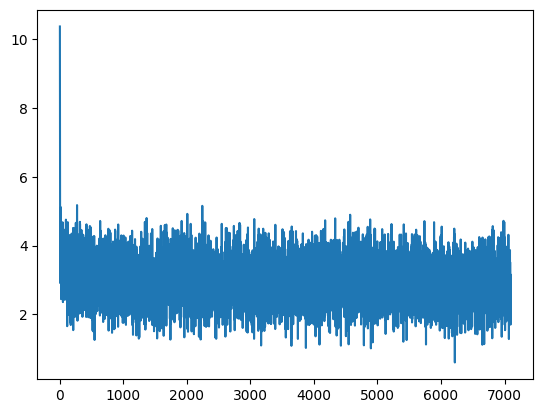

In [11]:
import matplotlib.pyplot as plt

plt.plot(torch.tensor(lossi))
plt.show()

In [12]:
with torch.no_grad():
    print(translator.generate("hello world"))
    print(translator.generate("I love You"))
    print(translator.generate("All roads lead to Rome"))

我 ， - ， ， ，
- ， ， -
- ， ， ， ， ， ，
